In [1]:
pip install matplotlib


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 5.1 MB/s eta 0:00:02
   ----- ---------------------------------- 1.0/8.3 MB 5.3 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.3 MB 3.9 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.3 MB 3.8 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.3 MB 3.8 MB/s eta 0:00:02
   ---------------------- ----------------- 4.7/8.3 MB 3.8 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.3 MB 3.8 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.3 MB 3.8 MB/s eta 0:00:01
   ---------------------------------- ----- 7.1/8.3 MB 3.8 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.3 MB 3.8 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 3.7 MB/s  0:00:02
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------------ -------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Vrushali\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Vrushali\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['font.family'] = 'DejaVu Sans'

print("Libraries ready!")

Libraries ready!


In [6]:
df = pd.read_csv('Student_performance_cleaned.csv')  

print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
df.head()

Rows: 2392  |  Columns: 15


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,Female,0,2,19.83,7,Yes,2,No,No,Yes,No,2.9292,2
1,1002,18,Male,0,1,15.41,0,No,1,No,No,No,No,3.0429,1
2,1003,15,Male,2,3,4.21,26,No,2,No,No,No,No,0.1126,4
3,1004,17,Female,0,3,10.03,14,No,3,Yes,No,No,No,2.0542,3
4,1005,17,Female,0,2,4.67,17,Yes,3,No,No,No,No,1.2881,4


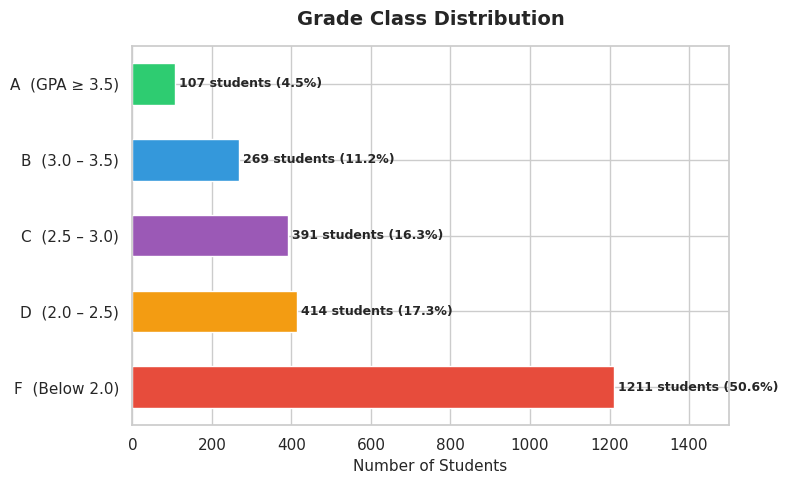

In [7]:
grade_counts = df['GradeClass'].value_counts().sort_index()
labels = ['A  (GPA ≥ 3.5)', 'B  (3.0 – 3.5)', 'C  (2.5 – 3.0)',
          'D  (2.0 – 2.5)', 'F  (Below 2.0)']
colors = ['#2ecc71', '#3498db', '#9b59b6', '#f39c12', '#e74c3c']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(labels, grade_counts.values, color=colors,
               edgecolor='white', height=0.55)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 10, bar.get_y() + bar.get_height() / 2,
            f'{w} students ({w/len(df)*100:.1f}%)',
            va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Number of Students', fontsize=11)
ax.set_title('Grade Class Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlim(0, 1500)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

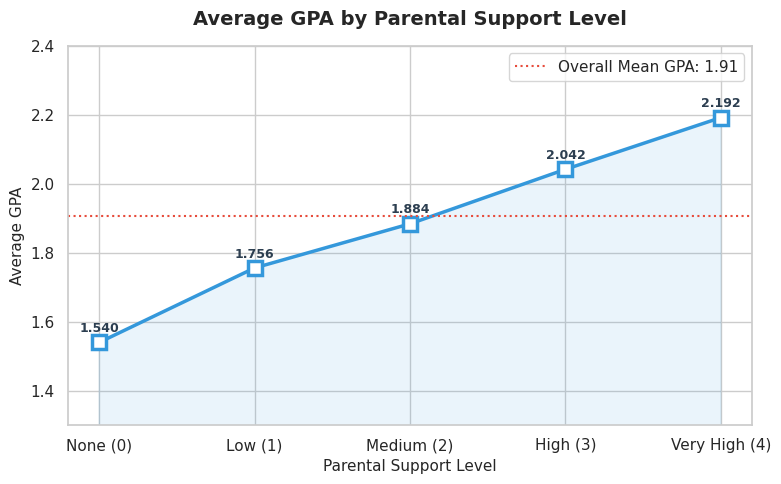

In [8]:
support_gpa = df.groupby('ParentalSupport')['GPA'].mean().round(3)
support_labels = ['None (0)', 'Low (1)', 'Medium (2)', 'High (3)', 'Very High (4)']

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(support_labels, support_gpa.values,
        color='#3498db', linewidth=2.5,
        marker='s', markersize=10,
        markerfacecolor='white', markeredgewidth=2.5,
        markeredgecolor='#3498db')

ax.fill_between(support_labels, support_gpa.values,
                alpha=0.1, color='#3498db')

for x, y in zip(support_labels, support_gpa.values):
    ax.text(x, y + 0.03, f'{y:.3f}', ha='center',
            fontsize=9, fontweight='bold', color='#2c3e50')

ax.set_ylim(1.3, 2.4)
ax.set_xlabel('Parental Support Level', fontsize=11)
ax.set_ylabel('Average GPA', fontsize=11)
ax.set_title('Average GPA by Parental Support Level', fontsize=14, fontweight='bold', pad=15)
ax.axhline(df['GPA'].mean(), color='#e74c3c', linestyle=':', linewidth=1.5,
           label=f'Overall Mean GPA: {df["GPA"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

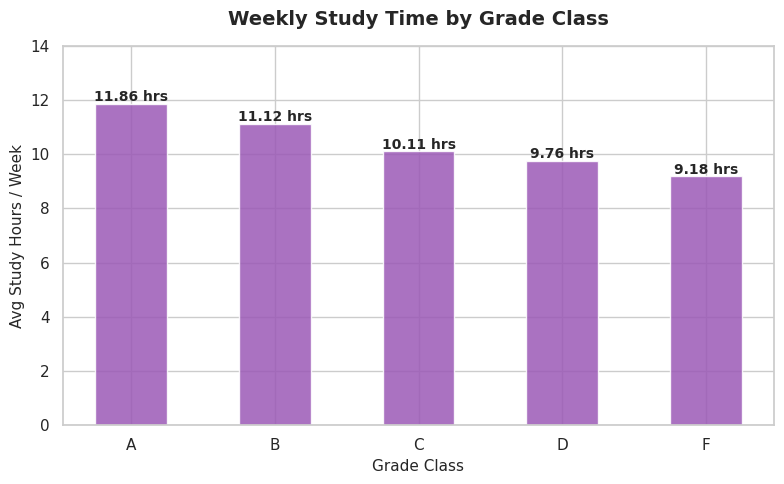

In [9]:
study_grade = df.groupby('GradeClass')['StudyTimeWeekly'].mean().round(2)
grade_labels = ['A', 'B', 'C', 'D', 'F']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(grade_labels, study_grade.values,
              color='#9b59b6', alpha=0.85, width=0.5, edgecolor='white')

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, h + 0.1,
            f'{h:.2f} hrs', ha='center', fontsize=10, fontweight='bold')

ax.set_ylim(0, 14)
ax.set_xlabel('Grade Class', fontsize=11)
ax.set_ylabel('Avg Study Hours / Week', fontsize=11)
ax.set_title('Weekly Study Time by Grade Class', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


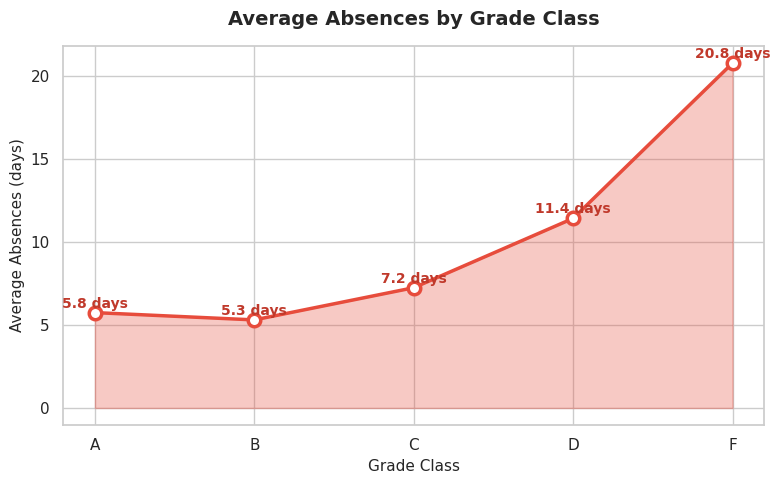

In [10]:
abs_grade = df.groupby('GradeClass')['Absences'].mean().round(2)
grade_labels = ['A', 'B', 'C', 'D', 'F']

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(grade_labels, abs_grade.values,
                color='#e74c3c', alpha=0.3)
ax.plot(grade_labels, abs_grade.values,
        color='#e74c3c', linewidth=2.5,
        marker='o', markersize=9, markerfacecolor='white',
        markeredgewidth=2.5, markeredgecolor='#e74c3c')

for x, y in zip(grade_labels, abs_grade.values):
    ax.text(x, y + 0.3, f'{y:.1f} days', ha='center',
            fontsize=10, fontweight='bold', color='#c0392b')

ax.set_xlabel('Grade Class', fontsize=11)
ax.set_ylabel('Average Absences (days)', fontsize=11)
ax.set_title('Average Absences by Grade Class', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

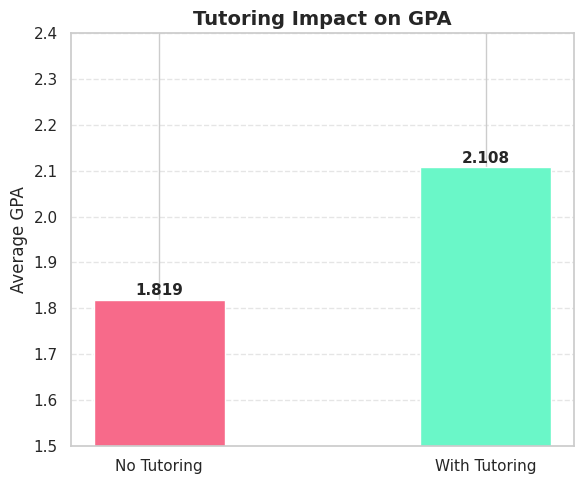

In [14]:
tutor_gpa = df.groupby('Tutoring')['GPA'].mean().round(3)
tutor_gpa.index = ['No Tutoring', 'With Tutoring']

plt.figure(figsize=(6, 5))
bars = plt.bar(tutor_gpa.index, tutor_gpa.values,
               color=['#f76a8a', '#6af7c8'], edgecolor='white', width=0.4)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{bar.get_height():.3f}', ha='center', fontsize=11, fontweight='bold')

plt.ylim(1.5, 2.4)
plt.ylabel('Average GPA')
plt.title('Tutoring Impact on GPA', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

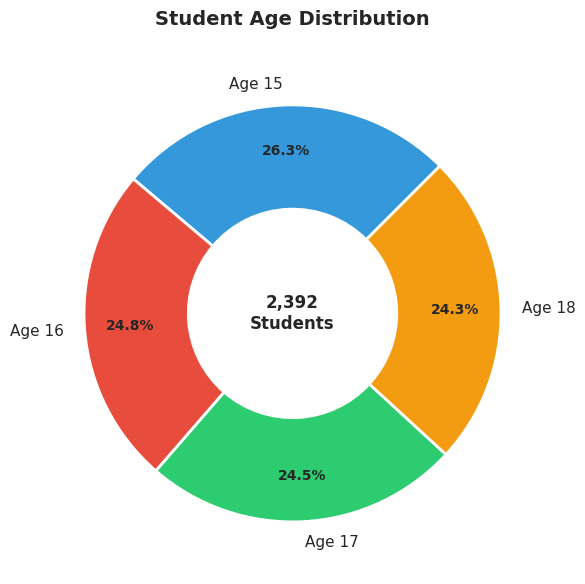

In [15]:
age_counts = df['Age'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 6))
wedges, texts, autotexts = ax.pie(
    age_counts.values,
    labels=[f'Age {a}' for a in age_counts.index],
    colors=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'],
    autopct='%1.1f%%',
    startangle=45,
    pctdistance=0.78,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')


ax.text(0, 0, f'{len(df):,}\nStudents', ha='center', va='center',
        fontsize=12, fontweight='bold')

ax.set_title('Student Age Distribution', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

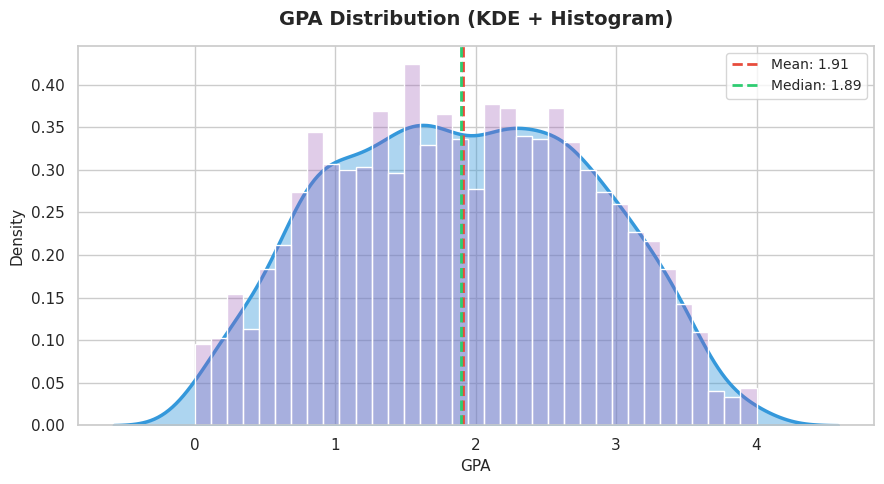

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.kdeplot(df['GPA'], fill=True, color='#3498db',
            alpha=0.4, linewidth=2.5, ax=ax)
sns.histplot(df['GPA'], bins=35, stat='density',
             color='#9b59b6', alpha=0.3, ax=ax)

ax.axvline(df['GPA'].mean(),   color='#e74c3c', linestyle='--',
           linewidth=2, label=f'Mean: {df["GPA"].mean():.2f}')
ax.axvline(df['GPA'].median(), color='#2ecc71', linestyle='--',
           linewidth=2, label=f'Median: {df["GPA"].median():.2f}')

ax.set_xlabel('GPA', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('GPA Distribution (KDE + Histogram)', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

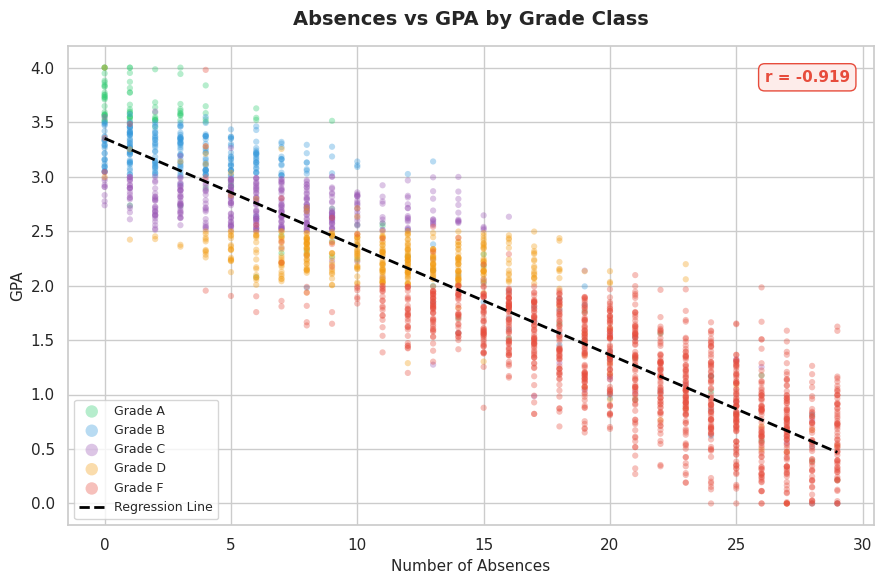

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))

grade_colors = {0.0: '#2ecc71', 1.0: '#3498db',
                2.0: '#9b59b6', 3.0: '#f39c12', 4.0: '#e74c3c'}
grade_names  = {0.0: 'A', 1.0: 'B', 2.0: 'C', 3.0: 'D', 4.0: 'F'}

for grade, grp in df.groupby('GradeClass'):
    ax.scatter(grp['Absences'], grp['GPA'],
               c=grade_colors[grade], alpha=0.35, s=20,
               label=f'Grade {grade_names[grade]}',
               edgecolors='none')


m, b = np.polyfit(df['Absences'], df['GPA'], 1)
x_vals = np.linspace(df['Absences'].min(), df['Absences'].max(), 100)
ax.plot(x_vals, m * x_vals + b, color='black', linewidth=2,
        linestyle='--', label='Regression Line')

r = df['Absences'].corr(df['GPA'])
ax.text(0.97, 0.95, f'r = {r:.3f}', transform=ax.transAxes,
        ha='right', va='top', fontsize=11, fontweight='bold',
        color='#e74c3c',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#fdecea', edgecolor='#e74c3c'))

ax.set_xlabel('Number of Absences', fontsize=11)
ax.set_ylabel('GPA', fontsize=11)
ax.set_title('Absences vs GPA by Grade Class', fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=9, markerscale=2)
plt.tight_layout()
plt.show()